# SARCASM DETECTION

<img src="https://m.media-amazon.com/images/I/713+UNN755L.jpg" width=300 height=600>


In this project, we have texts taken from Twitter. Some of these texts are sarcasm, and some are not. We will develop a sarcasm detection model. In addition to classification, we will experiment with deep learning.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#pip install "numpy==1.26.4" --force-reinstall

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score
from textblob import TextBlob

In [5]:
import re
import string
from bs4 import BeautifulSoup
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fatihozcan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/fatihozcan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fatihozcan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/fatihozcan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Loaading Data

In [6]:
df=pd.read_json('Sarcasm_Headlines_Dataset_v2.json', lines=True)

## EDA

In [7]:
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [8]:
df.tail()

,is_sarcastic,headline,article_link
28614,1,jews to celebrate rosh hashasha or something,https://www.theonion.com/jews-to-celebrate-ros...
28615,1,internal affairs investigator disappointed con...,https://local.theonion.com/internal-affairs-in...
28616,0,the most beautiful acceptance speech this week...,https://www.huffingtonpost.com/entry/andrew-ah...
28617,1,mars probe destroyed by orbiting spielberg-gat...,https://www.theonion.com/mars-probe-destroyed-...
28618,1,dad clarifies this not a food stop,https://www.theonion.com/dad-clarifies-this-no...


In [9]:
df.sample(3)

,is_sarcastic,headline,article_link
23671,0,'god called me here': meet the people of littl...,https://www.huffingtonpost.com/entry/god-calle...
21121,0,walmart customer fatally shoots teen accused o...,https://www.huffingtonpost.com/entry/customer-...
12478,1,teen scores awesome oral cancer poster,https://www.theonion.com/teen-scores-awesome-o...


In [10]:
df.shape

(28619, 3)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   is_sarcastic  28619 non-null  int64 
 1   headline      28619 non-null  object
 2   article_link  28619 non-null  object
dtypes: int64(1), object(2)
memory usage: 670.9+ KB


In [12]:
df.isnull().sum()

is_sarcastic    0
headline        0
article_link    0
dtype: int64

In [13]:
df.iloc[3]["headline"]

'inclement weather prevents liar from getting to work'

In [14]:
df['headline'].duplicated().sum()

116

In [15]:
df=df.drop(df[df['headline'].duplicated()].index, axis=0)

In [16]:
df.shape

(28503, 3)

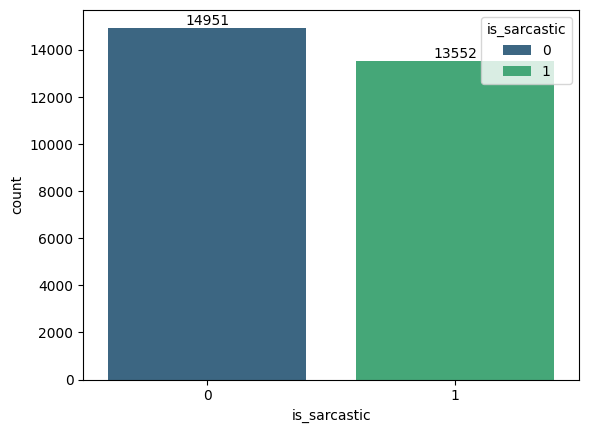

In [17]:
ax=sns.countplot(x=df['is_sarcastic'], hue=df['is_sarcastic'], palette='viridis');
for container in ax.containers:
    ax.bar_label(container)

## Preprocessing

### Text Split

In [18]:
df_ml=df.copy()

In [19]:
def clean_text(text):
    punctuation=string.punctuation
    stopwords=nltk.corpus.stopwords.words('english')
    lm=WordNetLemmatizer()
    # Clean html
    only_text=BeautifulSoup(text, "html.parser").get_text()
    # lover and punctuation
    text="".join([char.lower() for char in only_text if char not in punctuation])
    # clear  numbers
    text = re.sub(r'\d+', '', text)
    tokens=word_tokenize(text)
    # Drop Stopwordsleri and lemmatization
    final_text=" ".join([lm.lemmatize(word) for word in tokens if word not in stopwords])
    return final_text

In [20]:
df_ml['headline'][1]

'dem rep. totally nails why congress is falling short on gender, racial equality'

In [21]:
clean_text(df_ml['headline'][0])

'thirtysomething scientist unveil doomsday clock hair loss'

In [22]:
clean_text(df_ml['headline'][1])

'dem rep totally nail congress falling short gender racial equality'

In [23]:
x = df_ml['headline'].apply(clean_text)

In [24]:
y=df_ml['is_sarcastic']

In [25]:
x.shape

(28503,)

In [26]:
y.shape

(28503,)

## Text Vektorization

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
x_tfidf = vectorizer.fit_transform(x_train)

# Test verisini sadece transform ediyoruz
x_test_tfidf = vectorizer.transform(x_test)

### Three Classification Algorityms

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


nb_model = MultinomialNB()
nb_model.fit(x_tfidf, y_train)
nb_preds = nb_model.predict(x_test_tfidf)


lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_tfidf, y_train)
lr_preds = lr_model.predict(x_test_tfidf)

svc_model = LinearSVC()
svc_model.fit(x_tfidf, y_train)
svc_preds = svc_model.predict(x_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("SVC Accuracy:", accuracy_score(y_test, svc_preds))

Naive Bayes Accuracy: 0.7861778635327136
Logistic Regression Accuracy: 0.7877565339414138
SVC Accuracy: 0.7842483774776355


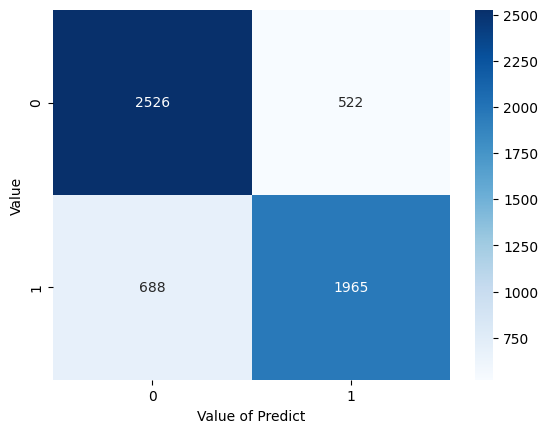

In [29]:

cm = confusion_matrix(y_test, lr_preds) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Value of Predict')
plt.ylabel('Value')
plt.show()

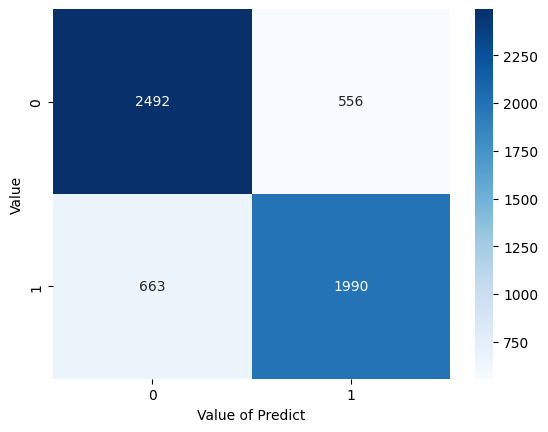

In [30]:
cm = confusion_matrix(y_test, nb_preds) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Value of Predict')
plt.ylabel('Value')
plt.show()

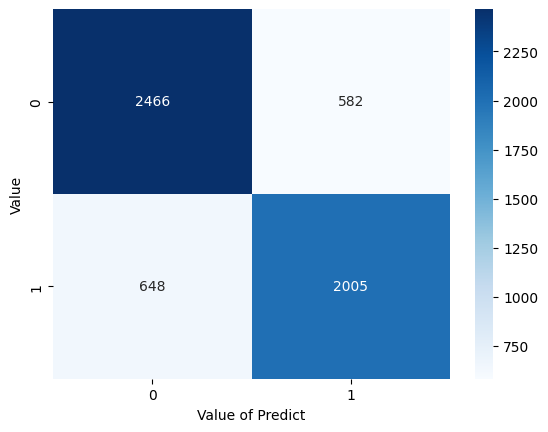

In [31]:
cm = confusion_matrix(y_test, svc_preds) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Value of Predict')
plt.ylabel('Value')
plt.show()

In [32]:
nb_y_pred = nb_model.predict(x_test_tfidf)
print(classification_report(y_test, nb_y_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      3048
           1       0.78      0.75      0.77      2653

    accuracy                           0.79      5701
   macro avg       0.79      0.78      0.78      5701
weighted avg       0.79      0.79      0.79      5701



In [33]:
lr_y_pred = lr_model.predict(x_test_tfidf)
print(classification_report(y_test, lr_y_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81      3048
           1       0.79      0.74      0.76      2653

    accuracy                           0.79      5701
   macro avg       0.79      0.78      0.79      5701
weighted avg       0.79      0.79      0.79      5701



In [34]:
svc_y_pred = svc_model.predict(x_test_tfidf)
print(classification_report(y_test, svc_y_pred))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80      3048
           1       0.78      0.76      0.77      2653

    accuracy                           0.78      5701
   macro avg       0.78      0.78      0.78      5701
weighted avg       0.78      0.78      0.78      5701



## Model Save

In [35]:
import joblib
joblib.dump(lr_model, 'sarcasm_lr_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## Reload Model and Test

In [36]:

loaded_model = joblib.load('sarcasm_lr_model.pkl')
loaded_vec = joblib.load('tfidf_vectorizer.pkl')

In [37]:
test_text=loaded_vec.transform(['inclement weather prevents liar from getting to work'])

In [38]:
loaded_model.predict(test_text)

array([0])

In [39]:
df['headline'][27689]

'area man regrets investing in facebook'

In [40]:
test_text=loaded_vec.transform(['area man regrets investing in facebook'])

In [41]:
loaded_model.predict(test_text)

array([1])

## Deep Learning Part

In [42]:
df_dl=df.copy()

In [43]:
x = df_dl['headline'].apply(clean_text)

In [44]:
y=df_dl['is_sarcastic']

In [45]:
x.shape

(28503,)

In [46]:
y.shape

(28503,)

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Tokenizer For Deep Learning

In [57]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Prepare tokenizer
max_words = 10000  # Frequently 1000 words
tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(x_train) # Only train data is fitted

# 2. Text to array
X_train_seq = tokenizer.texts_to_sequences(x_train)
X_test_seq = tokenizer.texts_to_sequences(x_test)

# 3. Padding
max_len = 50 
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

model.add(Embedding(max_words, 128, input_length=max_len))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid')) 

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

2026-05-09 12:41:51.908821: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-05-09 12:41:51.909361: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-09 12:41:51.909373: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-09 12:41:51.909633: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-09 12:41:51.909950: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [59]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor='val_loss', patience=10)

In [60]:

history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    verbose=1, callbacks=[early_stop]
)

Epoch 1/10


2026-05-09 12:41:55.512305: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


713/713 ━━━━━━━━━━━━━━━━━━━━ 3380s 5s/step - accuracy: 0.7482 - loss: 0.4972 - val_accuracy: 0.8027 - val_loss: 0.4275
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3474s 5s/step - accuracy: 0.8625 - loss: 0.3182 - val_accuracy: 0.8109 - val_loss: 0.4253
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3269s 5s/step - accuracy: 0.9088 - loss: 0.2220 - val_accuracy: 0.8078 - val_loss: 0.4657
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3177s 4s/step - accuracy: 0.9388 - loss: 0.1510 - val_accuracy: 0.7960 - val_loss: 0.5992
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3176s 4s/step - accuracy: 0.9565 - loss: 0.1092 - val_accuracy: 0.7899 - val_loss: 0.6809
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3259s 5s/step - accuracy: 0.9681 - loss: 0.0803 - val_accuracy: 0.7906 - val_loss: 0.8286
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3230s 5s/step - accuracy: 0.9765 - loss: 0.0607 - val_accuracy: 0.7846 - val_loss: 0.9564
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 3191s 4s/step - accuracy: 0.9819 - loss: 0.0468 - val_accurac

In [61]:
model.save('sarcasmDL.h5')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [62]:
model.save('sarcasmDL.keras')

In [63]:
print ('Accuracy: % {} '. format(history.history['accuracy'][-1]*100))

Accuracy: % 98.89483451843262 


In [64]:
print ('Validation Accuracy: % {} '. format(history.history['val_accuracy'][-1]*100)) 

Validation Accuracy: % 77.65304446220398 


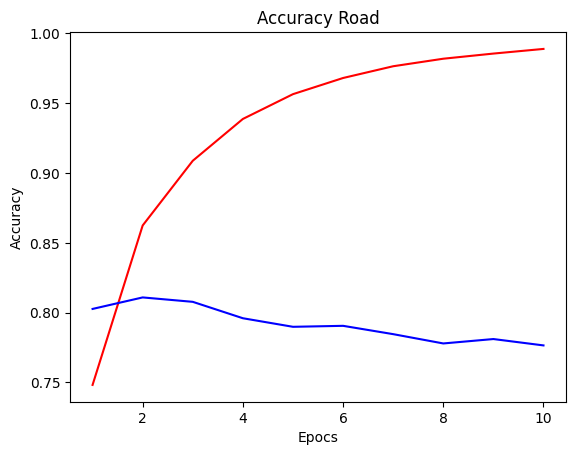

In [68]:
epocs=[i for i in range(1,11)]
plt.plot(epocs, history.history['accuracy'], color='red')
plt.plot(epocs, history.history['val_accuracy'], color='blue')
plt.xlabel('Epocs')
plt.ylabel('Accuracy')
plt.title('Accuracy Road')
plt.show()

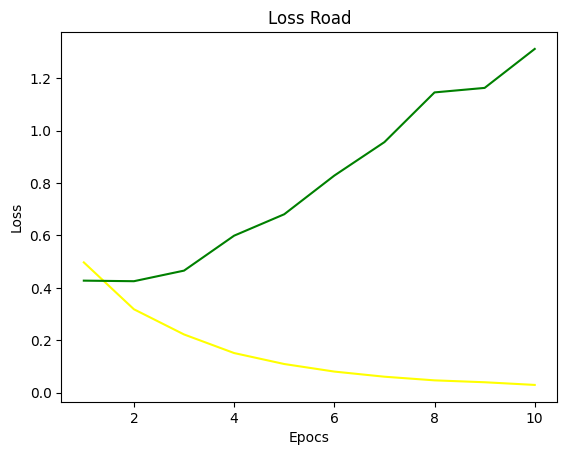

In [69]:
epocs=[i for i in range(1,11)]
plt.plot(epocs, history.history['loss'], color='yellow')
plt.plot(epocs, history.history['val_loss'], color='green')
plt.xlabel('Epocs')
plt.ylabel('Loss')
plt.title('Loss Road')
plt.show()

## Sentiment Analysis

In [27]:
all_words=" ".join(x).split()

In [28]:
from collections import Counter
from nltk.util import ngrams
bigrams=ngrams(all_words,2)
bigrams_counts=Counter(bigrams)

In [29]:
print("frequently used word groups")
for gram, count in bigrams_counts.most_common(10):
    print(f"{gram}: {count}")

frequently used word groups
('donald', 'trump'): 463
('area', 'man'): 260
('white', 'house'): 212
('hillary', 'clinton'): 178
('new', 'york'): 133
('study', 'find'): 131
('supreme', 'court'): 120
('bernie', 'sander'): 82
('high', 'school'): 79
('climate', 'change'): 76


In [52]:
trigrams = ngrams(all_words, 3)
trigram_counts = Counter(trigrams)


print("--- 15 Trigram ---")
for gram, count in trigram_counts.most_common(15):
  
    print(f"{' '.join(gram)}: {count}")

--- 15 Trigram ---
new study find: 35
new york time: 28
huffpost rise need: 22
rise need know: 22
new york city: 17
friday morning email: 15
donald trump say: 14
health care bill: 13
everything need know: 13
supreme court justice: 12
woman business qa: 12
donald trump jr: 12
saturday night live: 12
george w bush: 12
poll find american: 12


In [32]:
from textblob import TextBlob

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

df['subjectivity'] = x.apply(get_subjectivity)


In [34]:
df.sample(5)

,is_sarcastic,headline,article_link,subjectivity
19571,1,teen newsweek reports north korea is the bomb,https://www.theonion.com/teen-newsweek-reports...,0.00
14853,0,marvel releases full-sized teaser for 'ant-man...,https://www.huffingtonpost.com/entry/full-size...,0.00
17535,0,albert pujols and the end to down syndrome bul...,https://www.huffingtonpost.com/entry/albert-pu...,0.00
2009,0,december north dakota oil spill more than 3 ti...,https://www.huffingtonpost.com/entry/north-dak...,0.25
17246,0,27 perfect tweets about 'the bachelorette' sea...,https://www.huffingtonpost.com/entry/perfect-t...,1.00


In [53]:

subjectivity_comparison = df.groupby('is_sarcastic')['subjectivity'].mean()

print("Mean Score (0: Normal, 1: Sarcasm):")
print(subjectivity_comparison)

Mean Score (0: Normal, 1: Sarcasm):
is_sarcastic
0    0.264222
1    0.310346
Name: subjectivity, dtype: float64


## the text which is the sarcasm is more subjectivity.

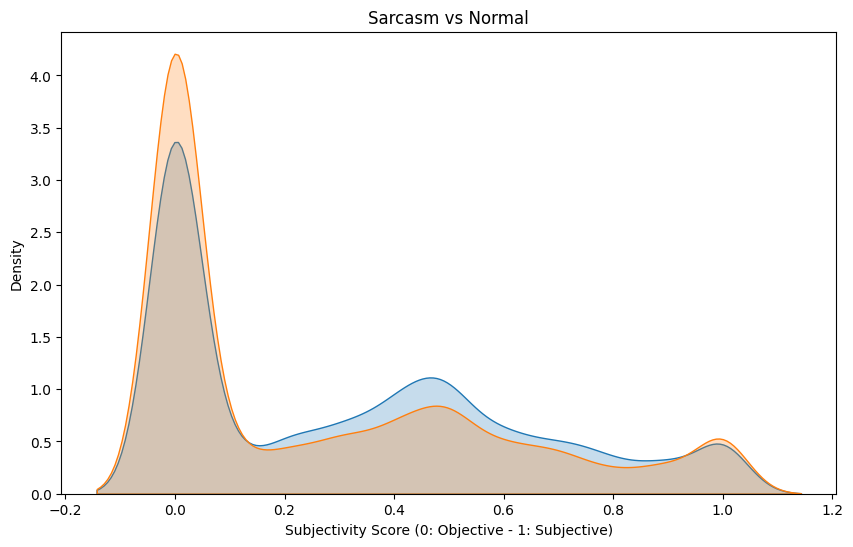

In [38]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['is_sarcastic'] == 1]['subjectivity'], label='Sarcastic', shade=True)
sns.kdeplot(df[df['is_sarcastic'] == 0]['subjectivity'], label='Normal', shade=True)
plt.title('Sarcasm vs Normal')
plt.xlabel('Subjectivity Score (0: Objective - 1: Subjective)')
plt.show()

In [47]:
from wordcloud import WordCloud

def generate_wordcloud(data, title):
    wc=WordCloud(width=800, height=400, background_color='white').generate(data)
    plt.figure(figsize=(10,5))
    img_array=np.array(wc.to_image())
    plt.imshow(img_array, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [48]:
sarcastic_text = " ".join(df[df['is_sarcastic'] == 1]['headline'])
normal_text = " ".join(df[df['is_sarcastic'] == 0]['headline'])

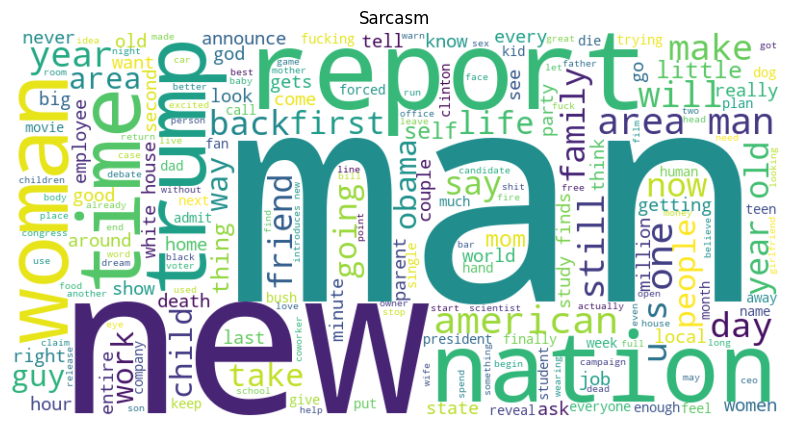

In [49]:
generate_wordcloud(sarcastic_text, 'Sarcasm')

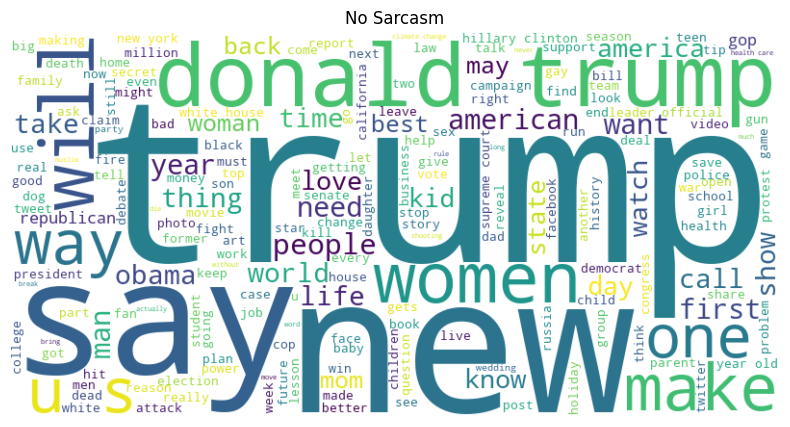

In [50]:
generate_wordcloud(normal_text, 'No Sarcasm')